# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Vincent Valentino | 5054251016 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from dython.nominal import associations
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [27]:
churn = pd.read_csv('data.csv')
display(churn.shape)
display(churn.head(25))

(7043, 21)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [28]:
churn = churn.drop(columns='customerID')
churn.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Terdapat ketidaksesuaian tipe data pada dua kolom utama. Kolom `TotalCharges` dianggap sebagai string, tetapi pada pemeriksaan head() terlihat seperti float. Sementara itu, kolom `SeniorCitizen` lebih tepat direpresentasikan sebagai data kategorikal biner (Yes/No) dibandingkan format numerik (dilihat dari `Partner` dan `Dependents`), sehingga penyesuaian tipe data pada kedua kolom ini perlu dilakukan terlebih dahulu.

In [29]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors= 'coerce')
churn["SeniorCitizen"]= churn["SeniorCitizen"].map({0: "No", 1: "Yes"})
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [30]:
print(churn.duplicated().sum())
display(churn.isnull().sum())

22


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
numerical = churn.select_dtypes(include= ['int64', 'float64']).columns
categorical = churn.select_dtypes(include= str).columns
display(churn[numerical].describe())
display(churn[categorical].describe())

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


Pemeriksaan data menunjukkan bahwa seluruh variabel numerik bernilai non-negatif ($\ge 0$) dan tidak ditemukan kolom kategorikal bernilai tunggal (constant feature).

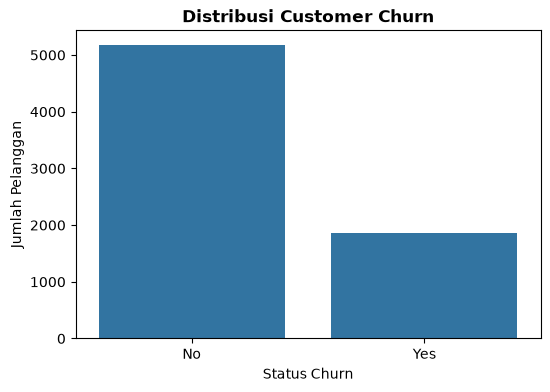

In [32]:
plt.figure(figsize=(6, 4))
sb.countplot(data=churn, x='Churn')
plt.title('Distribusi Customer Churn', fontsize=12, fontweight='bold')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')
plt.show()

Distribusi `Churn` sangat imbalanced, sehingga strategi penanganan kelas perlu diperhatikan saat training.

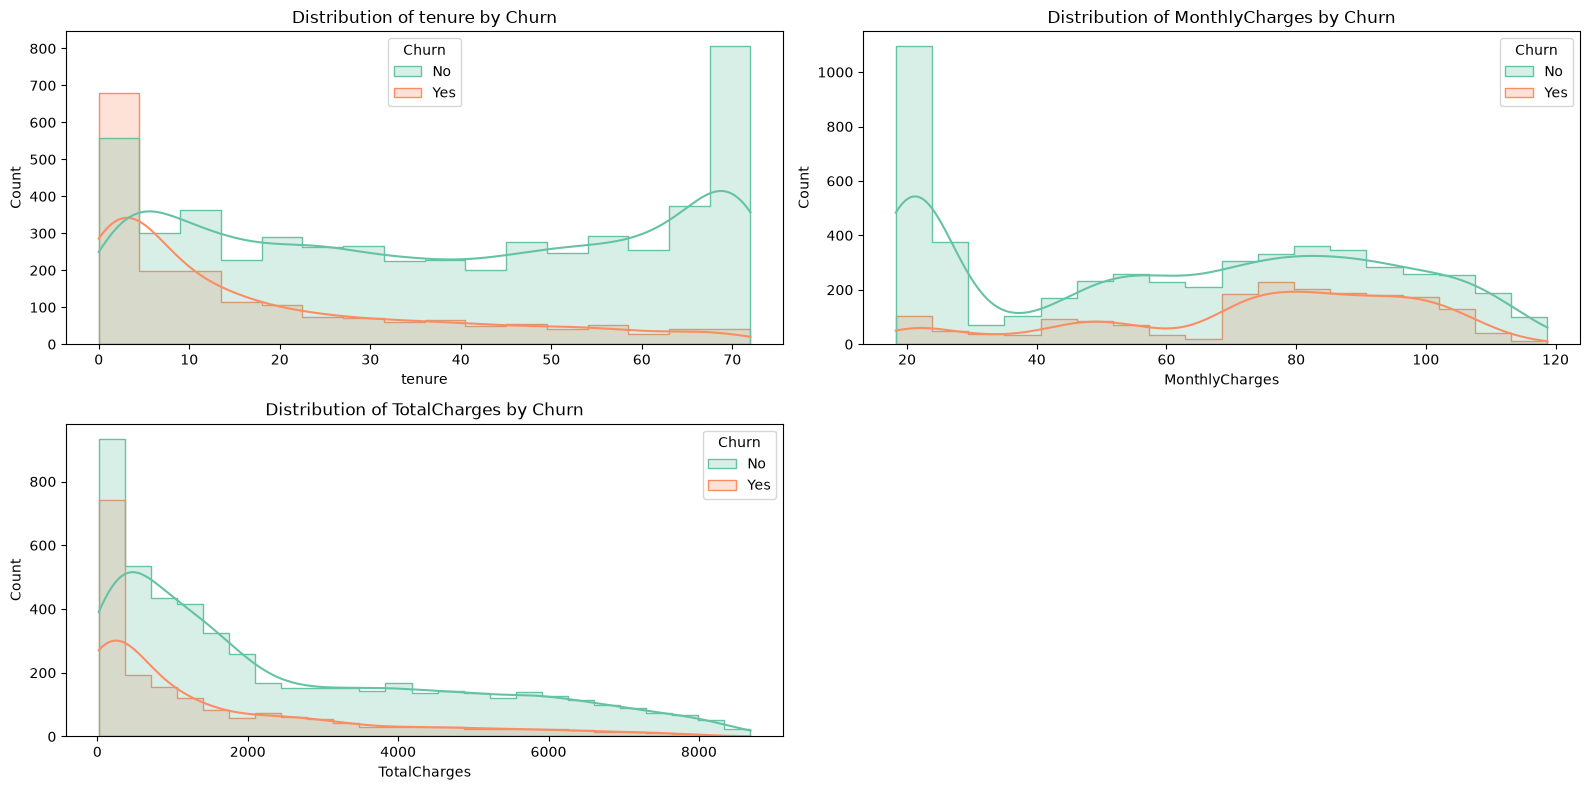

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, numerical):
    sb.histplot(data=churn, x=col, hue=churn['Churn'], kde=True, palette='Set2', element='step', ax=ax)
    ax.set_title(f'Distribution of {col} by Churn')
    ax.set_xlabel(col)

for ax in axes[len(numerical):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

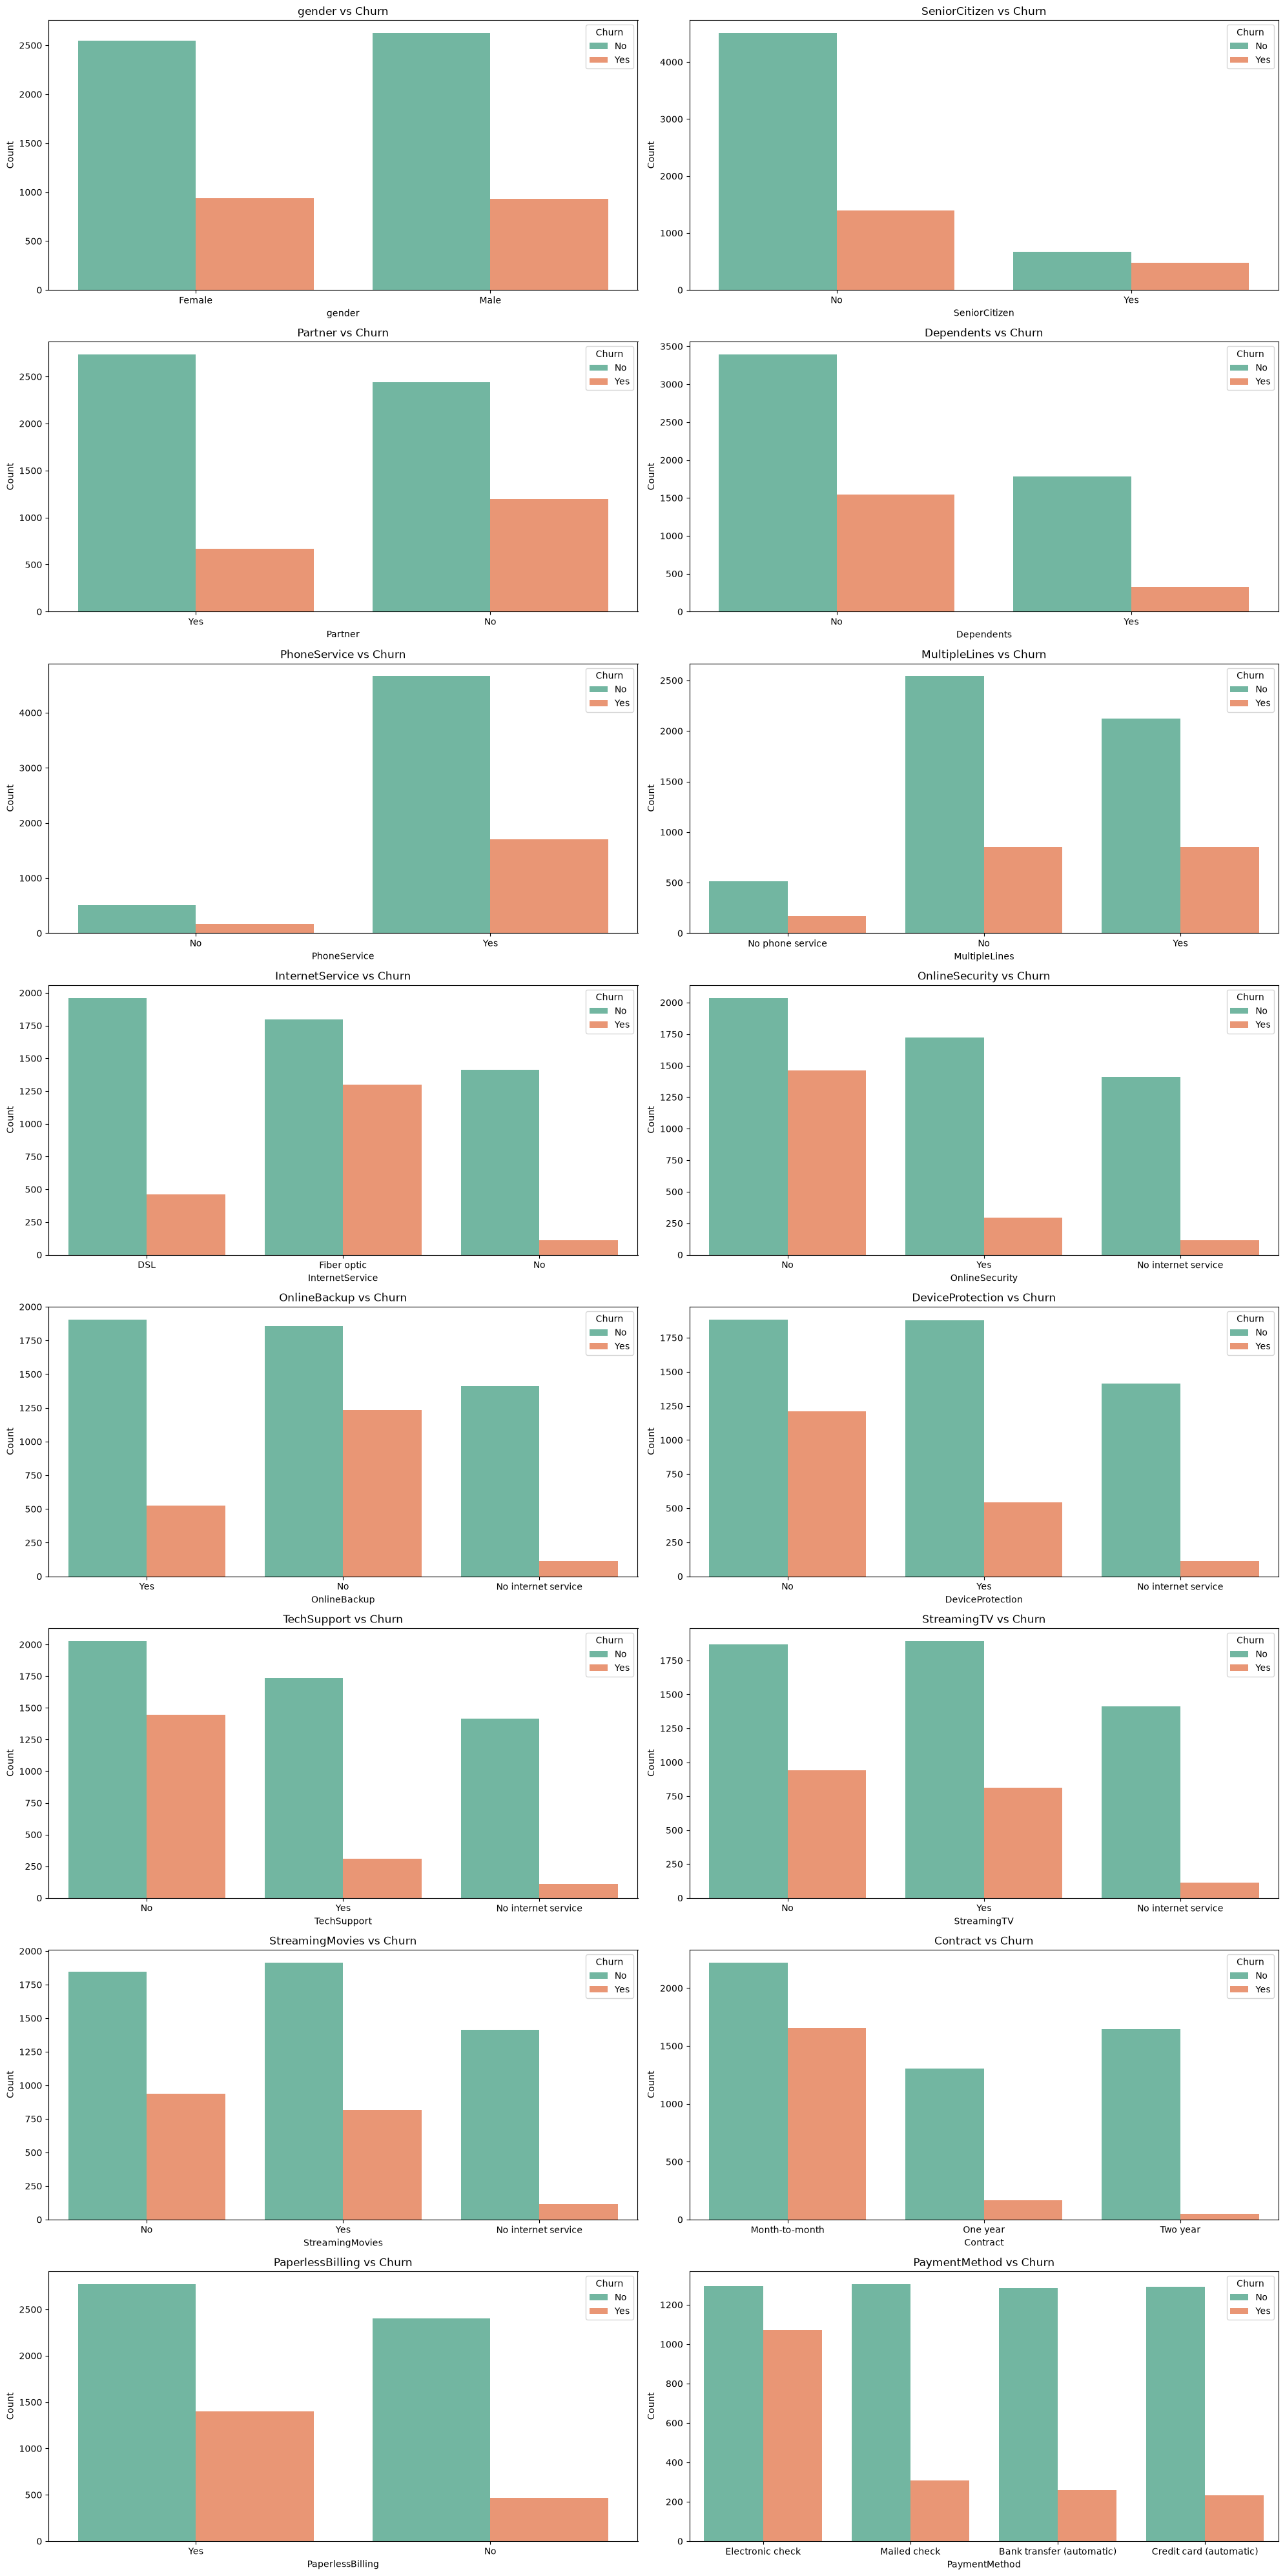

In [34]:
features = churn[categorical].drop(columns='Churn')
fig, axes = plt.subplots(8, 2, figsize=(20, 40))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sb.countplot(data=churn, x=col, hue=churn['Churn'], palette='Set2', ax=ax,)
    ax.set_title(f'{col} vs Churn')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

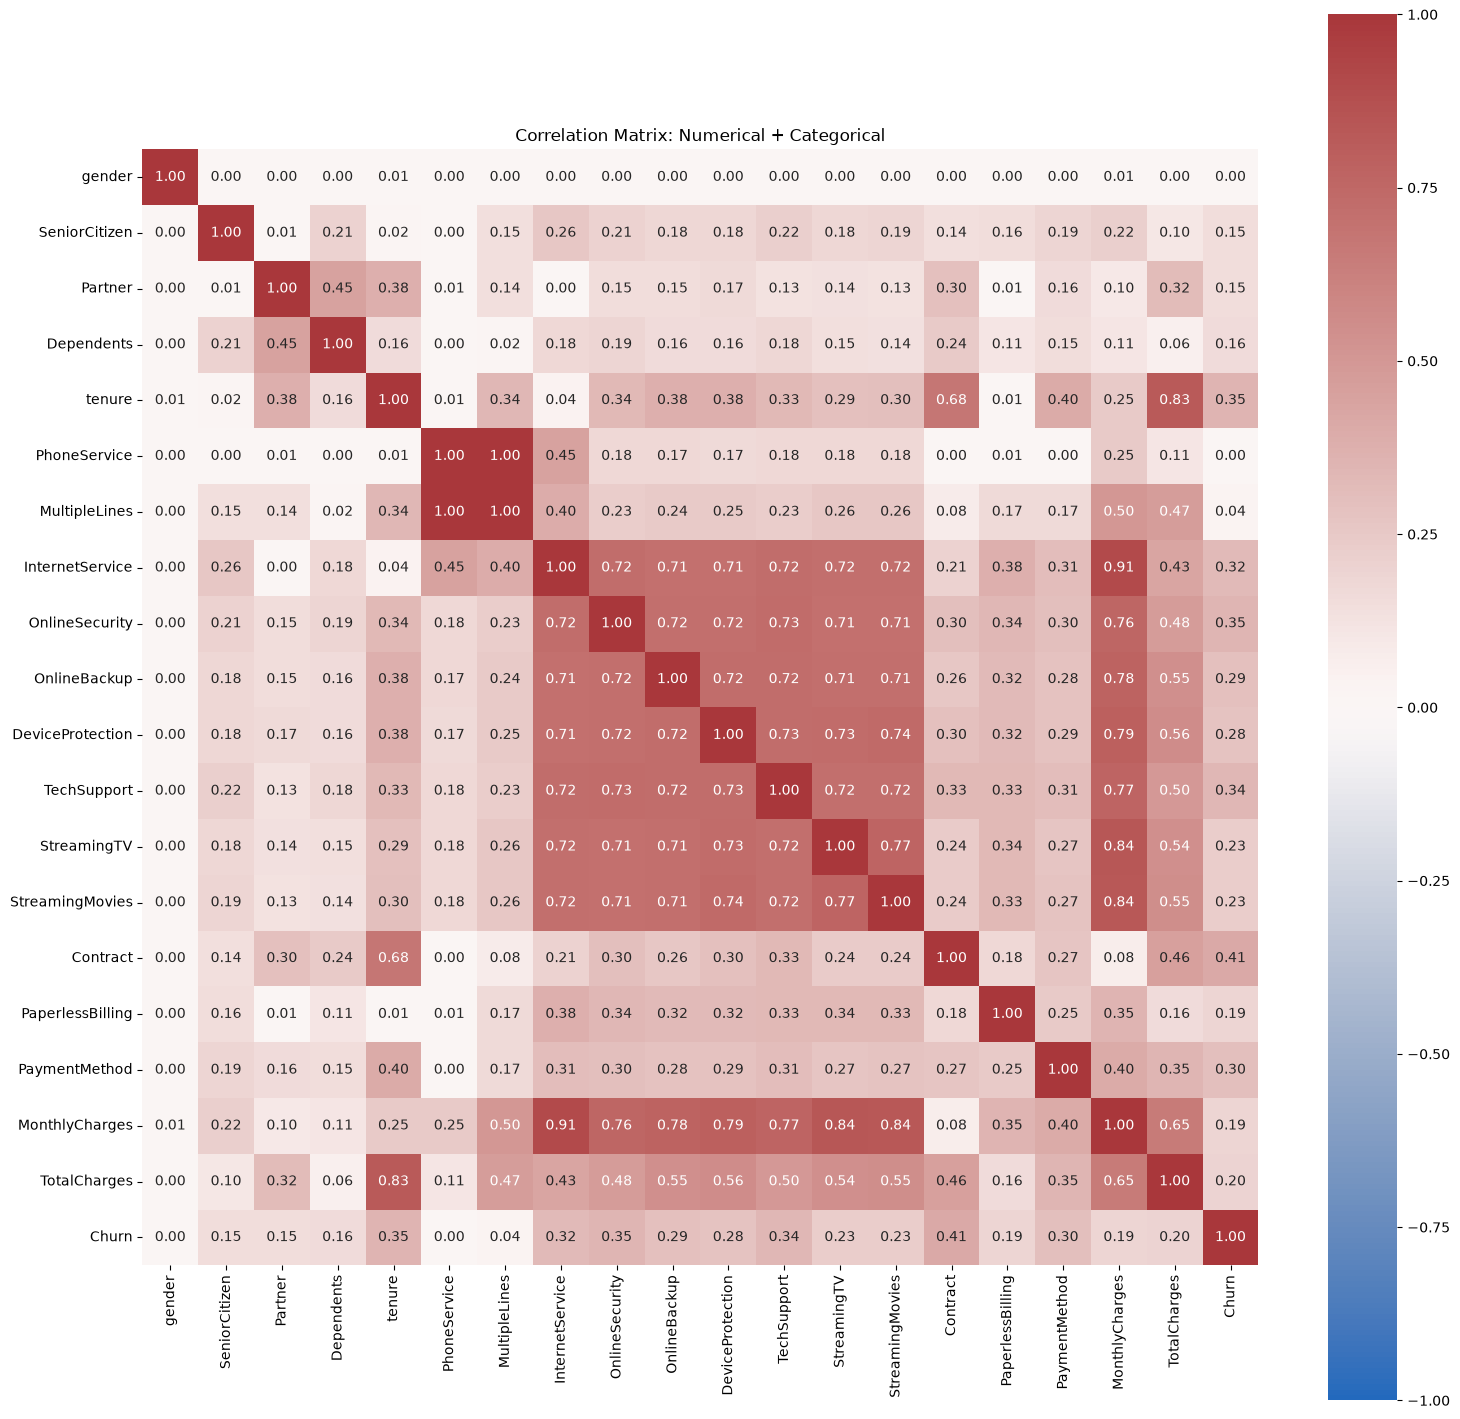

In [35]:
results = associations(churn, cmap="vlag", figsize=(18, 18), title="Correlation Matrix: Numerical + Categorical")

# 2. Preprocessing

In [36]:
churn = churn.drop_duplicates().reset_index(drop=True)
churn['TotalCharges'] = churn['TotalCharges'].fillna(churn['tenure'] * churn['MonthlyCharges'])

In [37]:
cat = categorical.drop('Churn')
encoder = OneHotEncoder(drop="first", sparse_output=False)
cat_encoded = encoder.fit_transform(churn[cat])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat),
    index=churn.index 
)

In [38]:
concatenated_df = pd.concat([churn[numerical], cat_encoded_df], axis=1)

In [39]:
x = concatenated_df
y = churn['Churn'].map({'No': 0, 'Yes': 1})
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) 

In [40]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [41]:
mlpc = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlpc.fit(x_train_scaled, y_train)
y_pred = mlpc.predict(x_test_scaled)

## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [42]:
activations = ['relu', 'tanh', 'logistic']
models = {}
rows = []
for act in activations:
    m = MLPClassifier(hidden_layer_sizes=(10, ), activation=act, solver='adam', max_iter=3000, random_state=42)
    m.fit(x_train_scaled, y_train)
    models[act] = m
    rows.append({
        'activation': act,
        'train_acc': accuracy_score(y_train, m.predict(x_train_scaled)),
        'test_acc': accuracy_score(y_test, m.predict(x_test_scaled)),
        'n_iter': m.n_iter_})

result_act = pd.DataFrame(rows).set_index('activation')
display(result_act.round(4))

,train_acc,test_acc,n_iter
activation,,,
relu,0.8214,0.7972,296
tanh,0.8232,0.7900,411
logistic,0.8120,0.8007,284


In [43]:
comparison = result_act[['test_acc']].rename(columns={'test_acc': 'Test Accuracy'})
comparison

,Test Accuracy
activation,
relu,0.797153
tanh,0.790036
logistic,0.800712


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [44]:
hidden = [(2,), (5,), (10,), (50,), (100, 50)]
layer = {}
rows = []
for h in hidden:
    m = MLPClassifier(hidden_layer_sizes=h, activation='logistic', solver='adam', max_iter=3000, random_state=42)
    m.fit(x_train_scaled, y_train)
    layer[h] = m
    rows.append({
        'hidden_layer_sizes': h,
        'train_acc': accuracy_score(y_train, m.predict(x_train_scaled)),
        'test_acc': accuracy_score(y_test, m.predict(x_test_scaled)),
        'n_iter': m.n_iter_})

result_hidden = pd.DataFrame(rows).set_index('hidden_layer_sizes')
display(result_hidden.round(4))

,train_acc,test_acc,n_iter
hidden_layer_sizes,,,
"(2,)",0.8072,0.7943,244
"(5,)",0.8088,0.7964,248
"(10,)",0.8120,0.8007,284
"(50,)",0.9115,0.7566,1854
"(100, 50)",0.9322,0.7302,1081


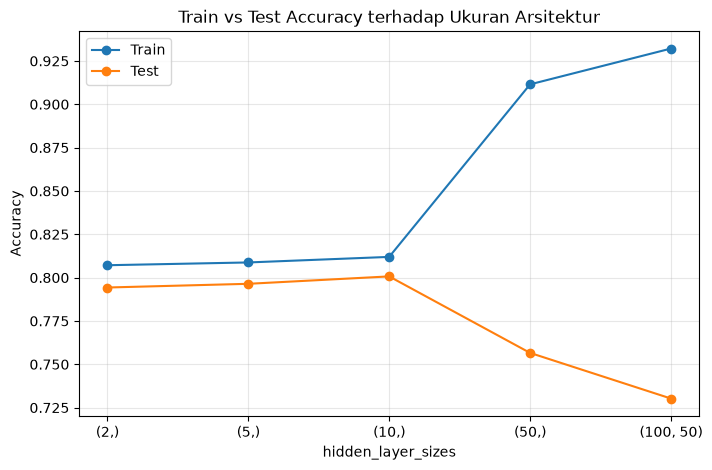

In [51]:
labels = [str(h) for h in result_hidden.index]
plt.figure(figsize=(8, 5))
plt.plot(labels, result_hidden['train_acc'], marker='o', label='Train')
plt.plot(labels, result_hidden['test_acc'], marker='o', label='Test')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy terhadap Ukuran Arsitektur')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Evaluasi Model

In [53]:
best_act = max(models, key=lambda a: accuracy_score(y_test, models[a].predict(x_test_scaled)))
best_arch = max(layer, key=lambda h: accuracy_score(y_test, layer[h].predict(x_test_scaled)))

candidates = {
    f'3.2 - activation={best_act}, (10,)': models[best_act],
    f'3.3 - activation=logistic, {best_arch}': layer[best_arch],
}

rows = []
for name, m in candidates.items():
    pred = m.predict(x_test_scaled)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
display(metrics_df.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
"3.2 - activation=logistic, (10,)",0.8007,0.662,0.5054,0.5732
"3.3 - activation=logistic, (10,)",0.8007,0.662,0.5054,0.5732


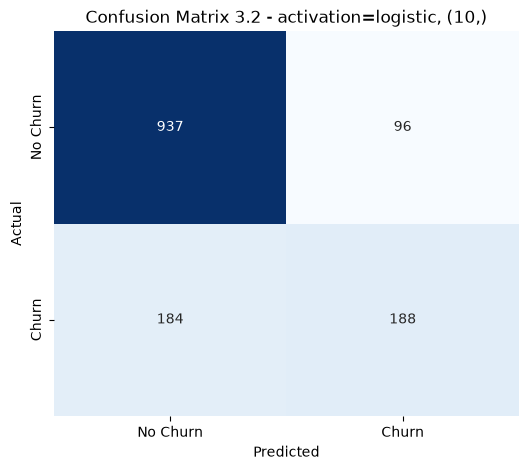

In [55]:
best_name = metrics_df['F1-Score'].idxmax()
best_model = candidates[best_name]
y_pred_best = best_model.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
           xticklabels=['No Churn', 'Churn'],
           yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix {best_name}')
plt.show()

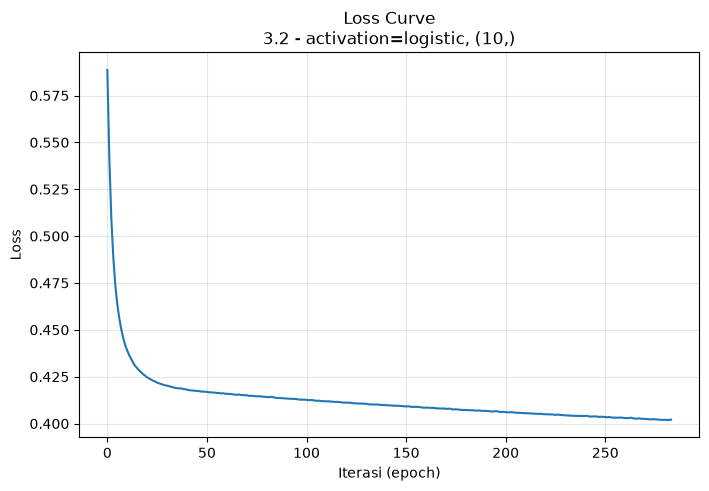

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(best_model.loss_curve_)
plt.xlabel('Iterasi (epoch)')
plt.ylabel('Loss')
plt.title(f'Loss Curve\n{best_name}')
plt.grid(alpha=0.3)
plt.show()

# 5. Analisis

#### 1. Perbandingan Fungsi Aktivasi (ReLU, Tanh, Logistic)

Dari hasil eksperimen dengan arsitektur tetap `hidden_layer_sizes=(10,)`, `solver='adam'`, `max_iter=3000`, dan `random_state=42`, diperoleh hasil sebagai berikut:

| Aktivasi | Train Accuracy | Test Accuracy | Iterasi (`n_iter_`) |
|----------|---------------|---------------|---------------------|
| **ReLU** | 82.14% | 79.72% | 296 |
| **Tanh** | 82.32% | 79.00% | 411 |
| **Logistic** | 81.20% | **80.07%** | 284 |

Berdasarkan tabel di atas, perbedaan performa ketiga fungsi aktivasi tidak signifikan, selisih test accuracy antara yang terbaik (Logistic: 80.07%) dan terburuk (Tanh: 79.00%) hanya sekitar **1.07%**.

Hal ini dapat terjadi karena beberapa alasan:
- Dataset Telco Customer Churn merupakan dataset tabular dengan fitur campuran (numerik dan kategorikal yang telah di-encode). Pada dataset jenis ini, perbedaan antar fungsi aktivasi cenderung kecil karena pola yang dipelajari umumnya tidak terlalu kompleks.
- Arsitektur yang kecil `(10,)` membatasi kapasitas model sehingga semua fungsi aktivasi berperilaku relatif serupa.
- *Logistic (Sigmoid)* memberikan test accuracy tertinggi meskipun train accuracy-nya paling rendah. Ini mengindikasikan bahwa Logistic memiliki sifat regularisasi implisit yang lebih baik yang dimana output-nya dibatasi antara 0 dan 1, sehingga gradien lebih stabil
- *Tanh* memiliki train accuracy tertinggi namun test accuracy terendah, menunjukkan sedikit kecenderungan overfitting dibanding fungsi aktivasi lainnya.
- *ReLU* berada di antara keduanya, dengan performa yang cukup seimbang.

Berdasarkan analisis ini, Logistic dipilih sebagai fungsi aktivasi terbaik untuk digunakan dalam eksperimen selanjutnya.

#### 2. Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Dengan menggunakan `activation='logistic'` (terbaik dari eksperimen sebelumnya), dilakukan pengujian terhadap berbagai ukuran arsitektur:

| Arsitektur (`hidden_layer_sizes`) | Train Accuracy | Test Accuracy | Gap (Train - Test) | Iterasi | Status |
|-----------------------------------|---------------|---------------|-------------------|---------|--------|
| **(2,)** | 80.72% | 79.43% | +1.29% | 244 | Normal / Sedikit underfit |
| **(5,)** | 80.88% | 79.64% | +1.24% | 248 | Normal |
| **(10,)** | 81.20% | **80.07%** | +1.13% | 284 | **Optimal** |
| **(50,)** | 91.15% | 75.66% | **+15.49%** | 1854 | **Overfitting parah** |
| **(100, 50)** | 93.22% | 73.02% | **+20.20%** | 1081 | **Overfitting kritis** |

**Temuan utama:**

- Pada arsitektur kecil `(2,)` hingga `(10,)`, gap antara train dan test accuracy sangat kecil dan stabil (sekitar 1.1% - 1.3%), menandakan generalisasi yang baik.
- Overfitting mulai terlihat jelas pada arsitektur `(50,)`, di mana terjadi bifurkasi tajam: train accuracy melonjak ke 91.15% sementara test accuracy justru turun ke 75.66% (gap = 15.49%). Model membutuhkan 1854 iterasi untuk konvergen, menandakan model berusaha terlalu keras menghafal noise pada data training.
- Pada `(100, 50)`, overfitting semakin parah dengan train accuracy mencapai 93.22% tetapi test accuracy justru turun lebih jauh ke 73.02% (gap = 20.20%).
- Kedua kurva berpisah secara signifikan pada arsitektur `(50,)` ke atas.
- Arsitektur optimal adalah `(10,)` karena memberikan keseimbangan terbaik antara kapasitas model dan kemampuan generalisasi.

#### 3. Analisis Loss Curve

Berdasarkan loss curve dari model terbaik `(10,), logistic`:

- Loss curve menurun dengan halus dan mendatar sebelum iterasi ke-300 (model konvergen pada `n_iter_=284` dari `max_iter=3000`).
- Ini membuktikan bahwa `max_iter=3000` lebih dari cukup dan tidak terjadi penghentian prematur.
- Model sudah cukup konvergen.

# 6. Kesimpulan dan Saran

#### Kesimpulan

Berdasarkan serangkaian eksperimen yang telah dilakukan pada dataset Telco Customer Churn menggunakan model ANN (MLPClassifier), dapat ditarik beberapa kesimpulan sebagai berikut:

1. **Fungsi aktivasi tidak berpengaruh signifikan pada arsitektur kecil.** Ketiga fungsi aktivasi (ReLU, Tanh, Logistic) menghasilkan performa yang relatif serupa pada arsitektur `(10,)`, dengan selisih test accuracy maksimal hanya ~1%. Fungsi Logistic terpilih sebagai yang terbaik dengan test accuracy 80.07% dan menunjukkan generalisasi paling baik (gap train-test terkecil).

2. **Ukuran arsitektur sangat berpengaruh terhadap overfitting.** Arsitektur yang terlalu besar (`(50,)` dan `(100, 50)`) menyebabkan overfitting parah, di mana train accuracy sangat tinggi (>90%) namun test accuracy justru menurun drastis (<76%). Arsitektur optimal untuk dataset ini adalah `(10,)` yang memberikan keseimbangan terbaik antara kapasitas dan generalisasi.

3. **Model terbaik yang dihasilkan** menggunakan konfigurasi `activation='logistic'`, `hidden_layer_sizes=(10,)`, `solver='adam'`, `max_iter=3000`, `random_state=42` dengan performa:
   - **Accuracy**: 80.07%
   - **Precision**: 66.20%
   - **Recall**: 50.54%
   - **F1-Score**: 57.32%

4. **Recall dan F1-Score yang relatif rendah** menunjukkan bahwa model kesulitan mendeteksi pelanggan yang benar-benar churn (kelas positif). Ini kemungkinan disebabkan oleh ketidakseimbangan kelas pada dataset di mana jumlah pelanggan yang tidak churn jauh lebih banyak daripada yang churn.

5. **Loss curve menunjukkan konvergensi yang baik**

#### Saran

Untuk meningkatkan performa model di masa mendatang, berikut beberapa rekomendasi:

1. Menangani ketidakseimbangan kelas (class imbalance).
2. Hyperparameter tuning dengan GridSearchCV atau RandomizedSearchCV.
3. Mencoba solver lain seperti `lbfgs` dan `sgd`.
4. Menambahkan regularisasi `alpha`.
5. Feature engineering yang lebih mendalam.